#  Text Classification

### A FIRST LOOK AT HUGGING FACE DATASETS

In [1]:
from huggingface_hub import list_datasets

all_datasets = list(list_datasets())

print(f"There are {len(all_datasets)} datasets currently available on the hub")
print(f"The first 10 are: {[d.id for d in all_datasets[:10]]}")

There are 493819 datasets currently available on the hub
The first 10 are: ['HuggingFaceFW/finepdfs', 'HuggingFaceM4/FineVision', 'jupyter-agent/jupyter-agent-dataset', 'fka/awesome-chatgpt-prompts', 'Pageshift-Entertainment/LongPage', 'SandboxAQ/SAIR', 'facebook/recycling_the_web', 'JDhruv14/Bhagavad-Gita_Dataset', 'Lk123/InfoSeek', 'continuedev/instinct-data']


**load the emotion dataset**

In [2]:
from datasets import load_dataset

emotions = load_dataset("emotion")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [5]:
text_ds = emotions["test"]
text_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})

In [6]:
len(train_ds), len(text_ds)

(16000, 2000)

In [7]:
train_ds[0:10]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy',
  'ive been feeling a little burdened lately wasnt sure why that was',
  'ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny',
  'i feel as confused about life as a teenager or as jaded as a year old man',
  'i have been with petronas for years i feel that petronas has performed well and made a huge profit',
  'i feel romantic too'],
 'label': [0, 0, 3, 2, 3, 0, 5, 4, 1, 2]}

In [8]:
train_ds.column_names

['text', 'label']

In [9]:
print(train_ds.features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


### From Datasets to a DataFrame

In [10]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [11]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)


df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Class Distribution

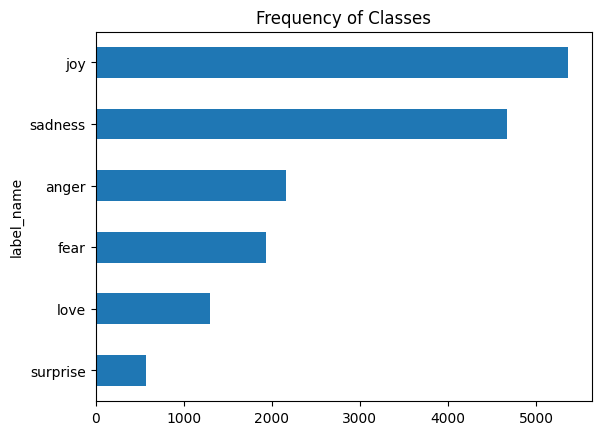

In [12]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

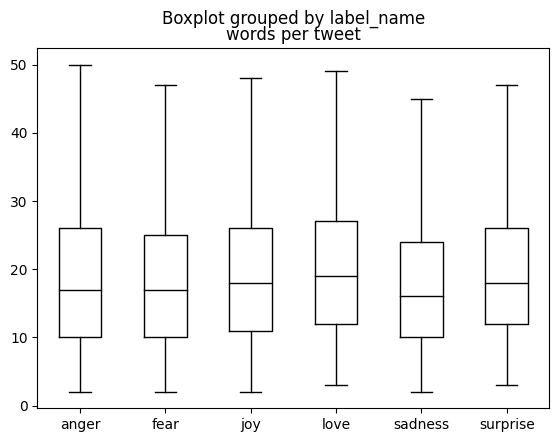

In [13]:
df["words per tweet"] = df["text"].str.split().apply(len)
df.boxplot(
    "words per tweet", by="label_name", grid=False, showfliers=False, color="black"
)
plt.xlabel("")
plt.show()

In [14]:
emotions.reset_format()  # Reset the output format of dataset since we dont need the DataFrame format anymore

### From Text to Tokens

#### *Character Tokenization*

**Creating a simple character tokens**

In [15]:
text = "tokenizing text is a core task of NLP."
tokenized = list(text)
print(tokenized)

['t', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


**Numericalization and encoding each unique token**

In [16]:
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenized)))}
print(token2idx)

{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'a': 5, 'c': 6, 'e': 7, 'f': 8, 'g': 9, 'i': 10, 'k': 11, 'n': 12, 'o': 13, 'r': 14, 's': 15, 't': 16, 'x': 17, 'z': 18}


In [17]:
input_ids = [token2idx[token] for token in tokenized]
print(input_ids)

[16, 13, 11, 7, 12, 10, 18, 10, 12, 9, 0, 16, 7, 17, 16, 0, 10, 15, 0, 5, 0, 6, 13, 14, 7, 0, 16, 5, 15, 11, 0, 13, 8, 0, 3, 2, 4, 1]


**encode the name of character in the Transformers TV series**

In [18]:
categorical_df = pd.DataFrame(
    {"name": ["Bublebee", "Optimus prime", "Megatron"], "Label ID": [0, 1, 2]}
)
categorical_df

,name,Label ID
0,Bublebee,0
1,Optimus prime,1
2,Megatron,2


In [19]:
pd.get_dummies(categorical_df["name"], dtype=int)
# now its one-hot encoded each colums has their 1 or 0

,Bublebee,Megatron,Optimus prime
0,1,0,0
1,0,0,1
2,0,1,0


In [20]:
import torch
import torch.nn.functional as F

inputs_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(inputs_ids, num_classes=len(token2idx))
one_hot_encodings.shape
# for each of the 38 input tokens we now have a one-hot vector with 19 dimensions

torch.Size([38, 19])

In [21]:
print(f"Token:{tokenized[0]}")
print(f"tensor index:{input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token:t
tensor index:16
One-hot: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])


#### Word Tokenization

In [22]:
tokenized_text = text.split()
print(tokenized_text)

['tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


#### *Subword Tokenization*

In [23]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [24]:
from transformers import DistilBertTokenizer

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)

In [25]:
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [26]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]']


In [27]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


In [28]:
tokenizer.vocab_size

30522

In [29]:
tokenizer.model_max_length

512

In [30]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

### Tokenizing the Whole Dataset

In [31]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [32]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [33]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [34]:
print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'attention_mask']


In [35]:
print(emotions_encoded["train"][:3])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong'], 'label': [0, 0, 3], 'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Training a Text Classifier

#### *Transformers as Feature Extractors*

**using another convenient auto class**
- similar to AutoTokenizer class `AutoModel`
- it has a `from_pretrained()` method to load the weights of a pretrained model

In [36]:
import torch
from transformers import AutoModel

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

2025-09-09 18:00:49.206139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757440849.459377      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757440849.531390      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

#### *Extracting the hidden states*

- lets retrive the last hidden states of a single string
- encode the string and convert the tokens to pytorch tensors


In [37]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [38]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"input tensor shape: {inputs['input_ids'].size()}")

input tensor shape: torch.Size([1, 6])


In [39]:
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [40]:
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

In [41]:
outputs.last_hidden_state[:, 0].size()

torch.Size([1, 768])

In [42]:
def extract_hidden_states(batch):
    inputs = {
        k: v.to(device) for k, v in batch.items() if k in tokenizer.model_input_names
    }
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    return {"hidden_state": last_hidden_state[:, 0].cpu().numpy()}

- only difference between this function and our previous logic is the final step 
- place the final hidden state back on CPU as Numpy Array 
- `map()` method  requires the processing function to return Python or NumPy 

In [43]:
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [44]:
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [45]:
emotions_hidden["train"].column_names

['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

#### *Creating a Feature matrix*

In [46]:
import numpy as np

X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

#### *Visualizing the training set*

In [47]:
import pandas as pd
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,4.369479,3.192785,0
1,-2.959343,3.760824,0
2,5.250896,6.771711,3
3,-2.434603,6.009598,2
4,-3.487948,5.520421,3


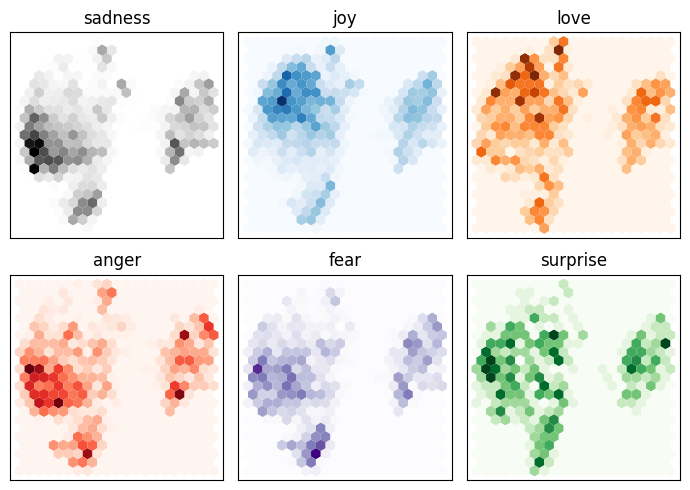

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(7, 5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(
        df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap, gridsize=20, linewidths=(0,)
    )
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()

#### *Training a simple classifier* 

In [49]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)
lr_clf.score(X_valid, y_valid)

0.6335

In [50]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

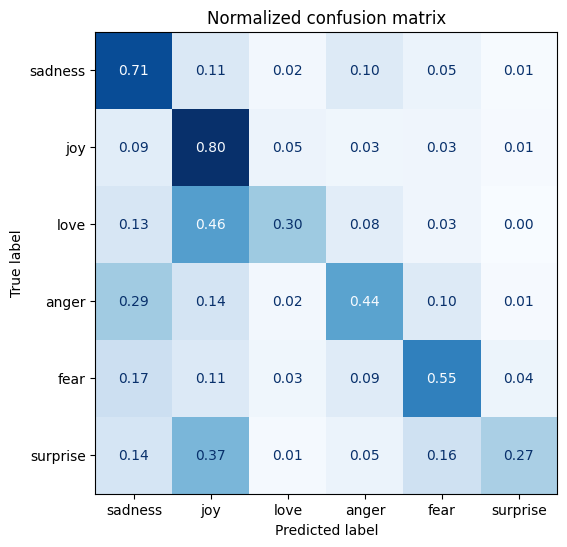

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()


y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

### Fine-Tuning Transformers


####  *Loading a Pretrained model*

In [52]:
from transformers import AutoModelForSequenceClassification

num_labels = 6
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=num_labels
).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### *Defining the performance metrics*

In [53]:
from sklearn.metrics import accuracy_score, f1_score


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

#### *Training the Model*

In [54]:
emotions_encoded = emotions_encoded.rename_column("label", "labels")

In [55]:
from huggingface_hub import login

login("Enter_your_token")

In [58]:
from transformers import Trainer, TrainingArguments

batch_size = 16
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    disable_tqdm=True,
    logging_steps=50,
    push_to_hub=False,
    log_level="error",
    report_to="none",
    fp16=True,
)

In [59]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    tokenizer=tokenizer,
)
trainer.train()

/tmp/ipykernel_36/747823217.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=training_args,


{'loss': 1.6101, 'grad_norm': 4.157369136810303, 'learning_rate': 1.951e-05, 'epoch': 0.05}
{'loss': 1.2445, 'grad_norm': 8.546646118164062, 'learning_rate': 1.902e-05, 'epoch': 0.1}
{'loss': 1.0222, 'grad_norm': 8.87956714630127, 'learning_rate': 1.8520000000000002e-05, 'epoch': 0.15}
{'loss': 0.7913, 'grad_norm': 10.307902336120605, 'learning_rate': 1.8030000000000002e-05, 'epoch': 0.2}
{'loss': 0.6412, 'grad_norm': 4.9784836769104, 'learning_rate': 1.753e-05, 'epoch': 0.25}
{'loss': 0.4611, 'grad_norm': 3.5844228267669678, 'learning_rate': 1.703e-05, 'epoch': 0.3}
{'loss': 0.4668, 'grad_norm': 5.181938171386719, 'learning_rate': 1.6530000000000003e-05, 'epoch': 0.35}
{'loss': 0.3771, 'grad_norm': 5.837460041046143, 'learning_rate': 1.603e-05, 'epoch': 0.4}
{'loss': 0.3376, 'grad_norm': 8.54692268371582, 'learning_rate': 1.5530000000000002e-05, 'epoch': 0.45}
{'loss': 0.3217, 'grad_norm': 3.527419328689575, 'learning_rate': 1.503e-05, 'epoch': 0.5}
{'loss': 0.3083, 'grad_norm': 1.091

In [60]:
pred_output = trainer.predict(emotions_encoded["validation"])

In [61]:
pred_output.metrics

{'test_loss': 0.15415635704994202,
 'test_accuracy': 0.9405,
 'test_f1': 0.9402422552408242,
 'test_runtime': 2.4386,
 'test_samples_per_second': 820.159,
 'test_steps_per_second': 51.26}

In [63]:
y_preds = np.argmax(pred_output.predictions, axis=1)

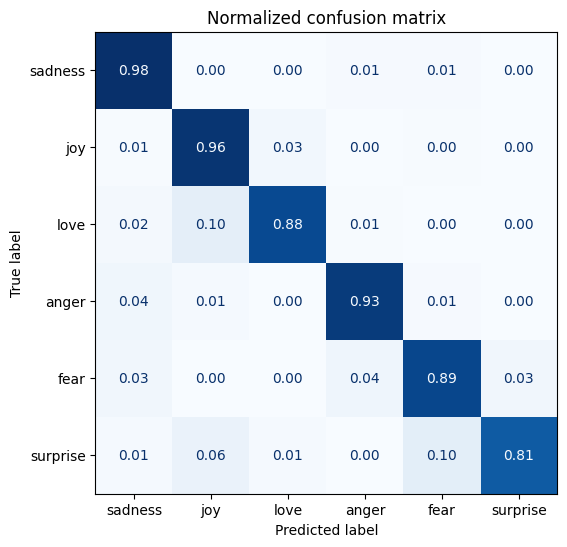

In [64]:
plot_confusion_matrix(y_preds, y_valid, labels)

#### *Error Analysis*

In [67]:
from torch.nn.functional import cross_entropy


def forward_pass_with_label(batch):
    inputs = {k: v.to(device) for k, v in batch.items()}
    if k in tokenizer.model_input_names:
        with torch.no_grad():
            output = model(**inputs)
            pred_label = torch.argmax(output.logits, axis=-1)
            loss = cross_entropy(
                output.logits, batch["label"].to(device), reduction="none"
            )
    return {"loss": loss.cpu().numpy(), "predicted_label": pred_label.cpu().numpy()}

In [69]:
emotions_encoded = emotions_encoded.rename_column("labels", "label")

In [74]:
from torch.nn.functional import cross_entropy
import torch


def forward_pass_with_label(batch):
    # Create a new dictionary to store inputs moved to the device
    inputs = {}
    for k, v in batch.items():
        # Check if the item is a PyTorch tensor before moving it to the device
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(device)
        else:
            # If it's not a tensor, keep it as is (e.g., lists)
            inputs[k] = v

    # Only pass model input names to the model
    model_inputs = {k: inputs[k] for k in inputs if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**model_inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        # Calculate loss using the original labels moved to the device
        loss = cross_entropy(output.logits, batch["label"].to(device), reduction="none")
    return {"loss": loss.cpu().numpy(), "predicted_label": pred_label.cpu().numpy()}

In [75]:
# Convert our dataset to pytorch tensors
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [78]:
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = df_test["predicted_label"].apply(label_int2str)

In [82]:
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1500,i guess we would naturally feel a sense of lon...,anger,sadness,7.121149
1111,im lazy my characters fall into categories of ...,joy,fear,6.796957
1963,i called myself pro life and voted for perry w...,joy,sadness,6.641062
177,im sure much of the advantage is psychological...,sadness,joy,6.325408
1950,i as representative of everything thats wrong ...,surprise,sadness,6.206969
1840,id let you kill it now but as a matter of fact...,joy,fear,6.190442
1509,i guess this is a memoir so it feels like that...,joy,fear,6.074420
1870,i guess i feel betrayed because i admired him ...,joy,sadness,6.012928
1658,i said before i feel like a hypocrite advocati...,love,anger,5.621648
1836,i got a very nasty electrical shock when i was...,fear,anger,5.609678


In [83]:
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1873,i feel practically virtuous this month i have ...,joy,joy,0.002089
632,i feel he is an terrific really worth bet,joy,joy,0.002145
133,i and feel quite ungrateful for it but i m loo...,sadness,sadness,0.002151
876,i feel like the cool mom,joy,joy,0.002153
669,i am not feeling very joyful today its been a ...,joy,joy,0.002166
222,i am at day and i am feeling terrific,joy,joy,0.002166
1263,i feel this way about blake lively,joy,joy,0.002170
697,i was missing him desperately and feeling idio...,sadness,sadness,0.002172
1082,i feel the cool night air against my face,joy,joy,0.002177
1502,i feel ungrateful for stupid shit like,sadness,sadness,0.002185


#### *Saving and shring the model*

In [84]:
trainer.push_to_hub(commit_message="Training completed!")

Uploading...:   0%|          | 0.00/268M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/swamimanish/distilbert-base-uncased-finetuned-emotion/commit/b6128e9de80d8190d07ecc7b99e9a917ddd11143', commit_message='Training completed!', commit_description='', oid='b6128e9de80d8190d07ecc7b99e9a917ddd11143', pr_url=None, repo_url=RepoUrl('https://huggingface.co/swamimanish/distilbert-base-uncased-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='swamimanish/distilbert-base-uncased-finetuned-emotion'), pr_revision=None, pr_num=None)

In [85]:
from transformers import pipeline

model_id = "swamimanish/distilbert-base-uncased-finetuned-emotion"

classifier = pipeline("text-classification", model=model_id)

config.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [87]:
custom_tweet = "I shaw a movie today and it was really good."
preds = classifier(custom_tweet, top_k=None)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


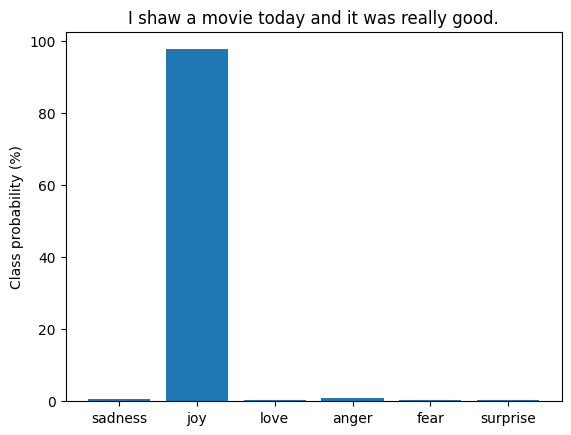

In [88]:
preds_df = pd.DataFrame(preds[0])
plt.bar(labels, 100 * preds_df["score"], color="C0")
plt.title(f"{custom_tweet}")
plt.ylabel("Class probability (%)")
plt.show()